## Introduction to K-Means Clustering

K-Means is one of the most popular unsupervised machine learning algorithms used for clustering.
Unlike classification, where we predict predefined labels, clustering aims to discover hidden patterns in unlabeled data.

The algorithm works in the following way:
Randomly initialize k centroids (cluster centers).
Assign each data point to the nearest centroid based on distance (usually Euclidean distance).
Update centroids by calculating the mean of all points assigned to each cluster.
Repeat steps 2 and 3 until centroids no longer change significantly (convergence).

## Key Features of K-Means:

Simple and efficient for large datasets.

Groups similar data points together.

Works best when clusters are roughly spherical and balanced.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from K_Mean import run_kmeans   
import joblib

In [2]:
data = pd.read_csv("Live.csv")

print("Dataset shape:", data.shape)
print("Columns:", data.columns.tolist())
data.head()

Dataset shape: (7050, 16)
Columns: ['status_id', 'status_type', 'status_published', 'num_reactions', 'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys', 'Column1', 'Column2', 'Column3', 'Column4']


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [3]:
numeric_cols = [
    "num_reactions", "num_comments", "num_shares",
    "num_likes", "num_loves", "num_wows",
    "num_hahas", "num_sads", "num_angrys"
]

data_numeric = data[numeric_cols]

print("Numeric dataset shape:", data_numeric.shape)
data_numeric.head()

Numeric dataset shape: (7050, 9)


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,529,512,262,432,92,3,1,1,0
1,150,0,0,150,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0
3,111,0,0,111,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0


In [4]:
data_numeric = data_numeric.dropna()

print("After dropping NaNs:", data_numeric.shape)

After dropping NaNs: (7050, 9)


In [5]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

# Save scaler for future use
joblib.dump(scaler, "scaler.pkl")

print("Scaled data shape:", data_scaled.shape)
print("Any NaNs in scaled?", np.isnan(data_scaled).sum())

Scaled data shape: (7050, 9)
Any NaNs in scaled? 0


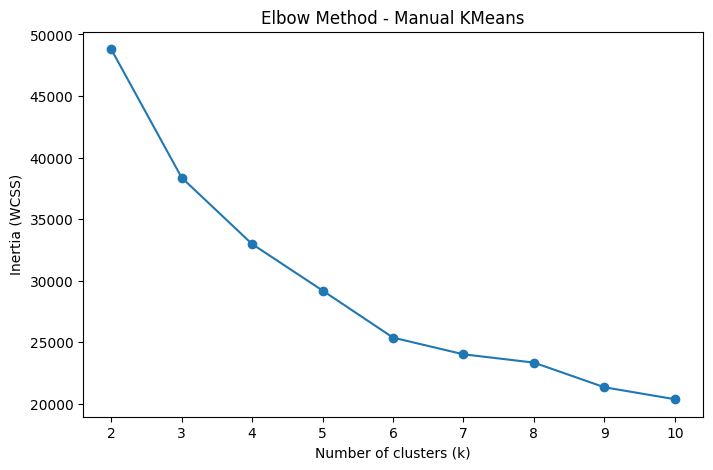

In [6]:
k_values = range(2, 11)
inertias = []

for k in k_values:
    _, _, inertia = run_kmeans(data_scaled, k=k)
    inertias.append(inertia)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method - Manual KMeans")
plt.show()

In [7]:
best_k = 3   # you can choose after looking at elbow graph
centroids, labels, inertia = run_kmeans(data_scaled, k=best_k)

print("Final Inertia:", inertia)
print("Centroids shape:", centroids.shape)

Final Inertia: 38373.89789463232
Centroids shape: (3, 9)


In [8]:
joblib.dump((centroids, labels), "kmeans_model.pkl")
print("Model saved successfully!")

Model saved successfully!
